In [1]:
## Ensemble Learning is a machine learning approach that combines multiple weak learners to construct a more powerful prediction model.
## 3 types of Ensemble Methods
#1.Bagging :Ask 10 doctors independently, then average their answers.
#2. Boosting: Doctor 1 gives diagnosis. Doctor 2 reviews mistakes. Doctor 3 reviews remaining mistakes.
#3.Stacking : Ask a surgeon, a radiologist, and a GP. Then have a chief doctor decide who to trust.


## HistgradientBoosting

In [ ]:
## we have basic gradient boosting methods called histgradientboosting (for both regression and classification)
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load data
data = load_iris()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = HistGradientBoostingClassifier(
    max_iter=100,          # Number of boosting iterations
    max_depth=3,           # Maximum depth of trees
    learning_rate=0.1,     # Step size shrinkage
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# model = HistGradientBoostingClassifier(
#     max_iter=100,          # Number of trees (like n_estimators)
#     max_depth=3,           # Maximum tree depth
#     learning_rate=0.1,     # How fast to learn (smaller = more robust)
#     max_leaf_nodes=31,     # Maximum leaves per tree
#     min_samples_leaf=20,   # Minimum samples in a leaf
#     l2_regularization=0.0, # Regularization strength
#     random_state=42,       # For reproducibility
#     verbose=0              # 0=silent, 1=progress bar
# )

/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Accuracy: 1.000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [3]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Create simple regression data
X, y = make_regression(n_samples=5000, n_features=5, noise=10, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.3f}")

MSE: 429.32
R² Score: 0.980


## Bagging


In [18]:
#1.Bagging == Bootstrap aggregating(Randomly sample your data with replacement ).
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, ValidationCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
X, y = make_classification(
    n_samples = 500,
    n_features= 10,
    n_informative= 8,
    n_redundant= 2,
    random_state= 42,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)


In [4]:
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
0,1.899136,-0.504262,-1.865578,2.383487,0.734764,1.105161,-2.229556,1.403973,-1.060674,-0.500870
1,2.467613,-3.406937,1.849073,1.470365,1.711802,-0.961105,-1.671268,0.039823,-1.258042,-1.077519
2,2.644711,0.889965,5.222994,-1.878677,-1.520034,3.023644,-0.447476,0.413821,-0.901039,-1.570579
3,5.766245,-0.878676,-1.187759,9.121980,0.398671,-2.391950,-4.457044,-1.512490,0.718755,0.302933
4,-0.689113,-1.485219,1.607958,-1.439935,0.853096,0.712017,-0.154815,0.309090,-1.785011,1.235665


In [5]:
## single Tree
single_tree = DecisionTreeClassifier(random_state= 42)
single_tree.fit(X_train, y_train)
single_pred = single_tree.predict(X_test)
single_tree_acc = accuracy_score(y_test, single_pred)
single_tree_acc

0.91

In [16]:
## Bagging ensemble
bagging = BaggingClassifier(
    estimator= DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf= 10,
        min_samples_split= 20,
        max_features=0.5
        ),
    n_estimators= 200, ## 50 trees
    random_state= 42
)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)
bagging_acc = accuracy_score(y_test, bagging_pred)
bagging_acc

0.85

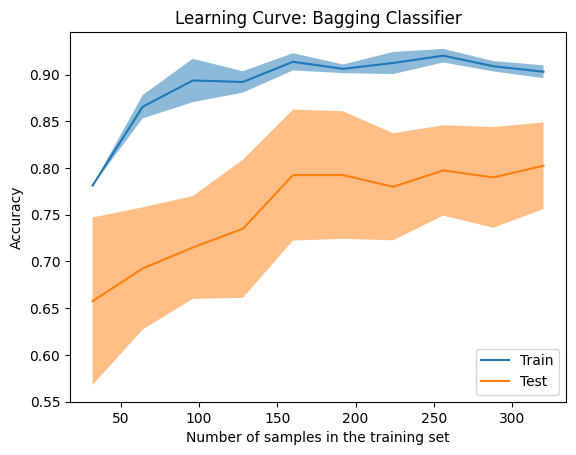

Train Accuracy: 0.9100
Test Accuracy: 0.8500
Gap (Overfitting indicator): 0.0600


In [17]:
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt

# Your trained bagging model
LearningCurveDisplay.from_estimator(
    bagging,  
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)
plt.title('Learning Curve: Bagging Classifier')
plt.show()

# Also print the final gap
train_score = bagging.score(X_train, y_train)
test_score = bagging.score(X_test, y_test)
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")
print(f"Gap (Overfitting indicator): {train_score - test_score:.4f}")

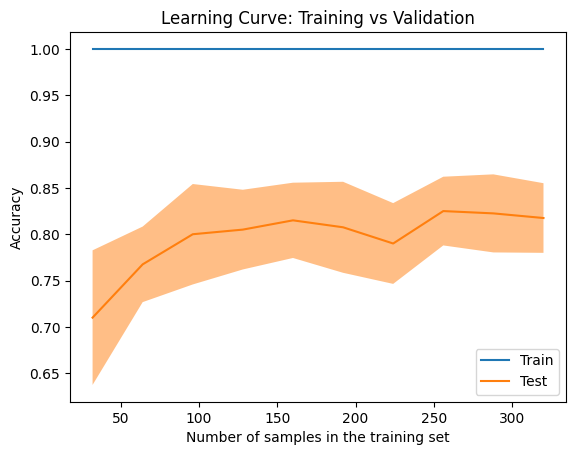

In [10]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None), n_estimators=200, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)
plt.title('Learning Curve: Training vs Validation')
plt.show()

In [20]:
## let's try Random Forest
rf = RandomForestClassifier(
    n_estimators= 200,
    max_depth= 5, 
    min_samples_split= 20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state= 42
)
rf.fit(X_train, y_train)
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print(f"Random Forest:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Gap: {train_acc - test_acc:.4f}")


Random Forest:
Train Accuracy: 0.9100
Test Accuracy: 0.8300
Gap: 0.0800


## Boosting

In [22]:
## AdaBoost
X, y = make_classification(
    n_samples= 500,
    n_features= 10, 
    n_informative= 8,
    n_redundant= 2,
    random_state= 42
)
# Convert labels to -1 and 1 (standard for AdaBoost)
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.3, random_state= 32)

In [37]:
from sklearn.ensemble import AdaBoostClassifier


ada = AdaBoostClassifier(
    estimator= DecisionTreeClassifier(max_depth= 5),
    n_estimators= 200,
    learning_rate= 1.0
)
ada.fit(X_train, y_train)
predictions = ada.predict(X_test)
accuracy_score(predictions, y_test)

0.8933333333333333

<Axes: xlabel='feature'>

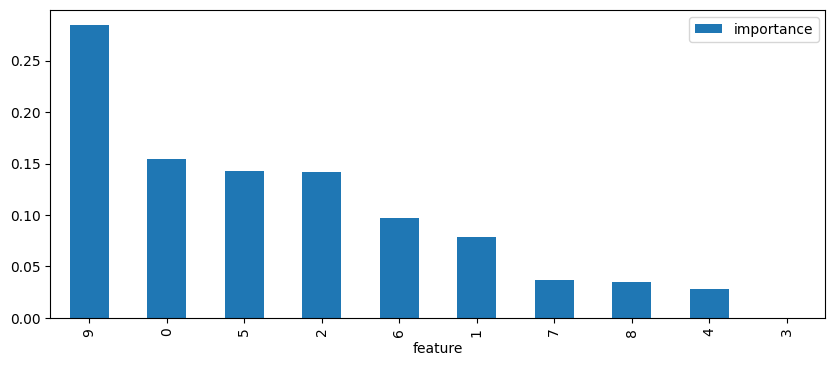

In [26]:
import pandas as pd

# Get feature importance
importance = pd.DataFrame({
    'feature': range(X.shape[1]),
    'importance': ada.feature_importances_
}).sort_values('importance', ascending=False)

# Plot
importance.plot(x='feature', y='importance', kind='bar', figsize=(10, 4))

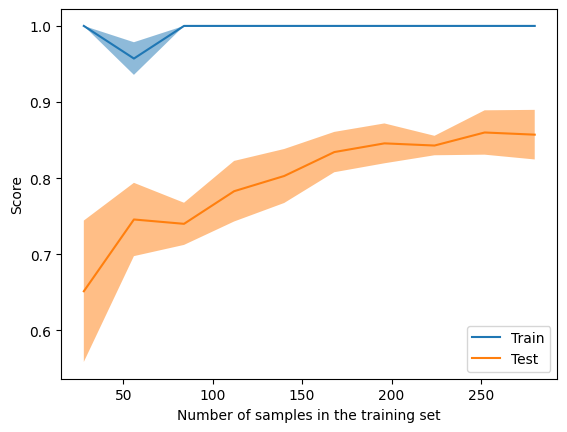

In [38]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(ada, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10))

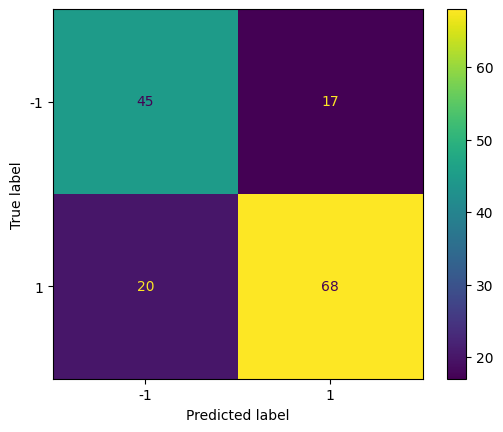

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(ada, X_test, y_test)

## Gradient Boosting regression

In [14]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version

In [8]:
data = load_diabetes()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.1, random_state= 42)


In [19]:
reg = GradientBoostingRegressor(
    n_estimators= 500,
    max_depth= 4, 
    min_samples_split=5, 
    learning_rate= 0.01,
    subsample= 0.5
)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)


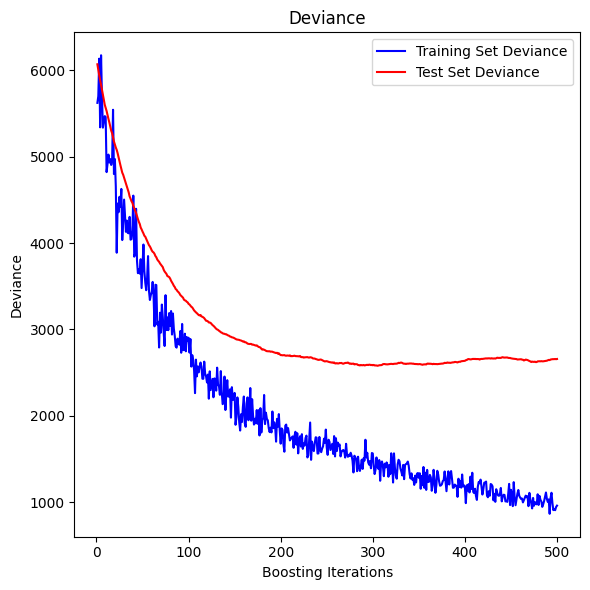

In [20]:
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}
test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(reg.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    reg.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()


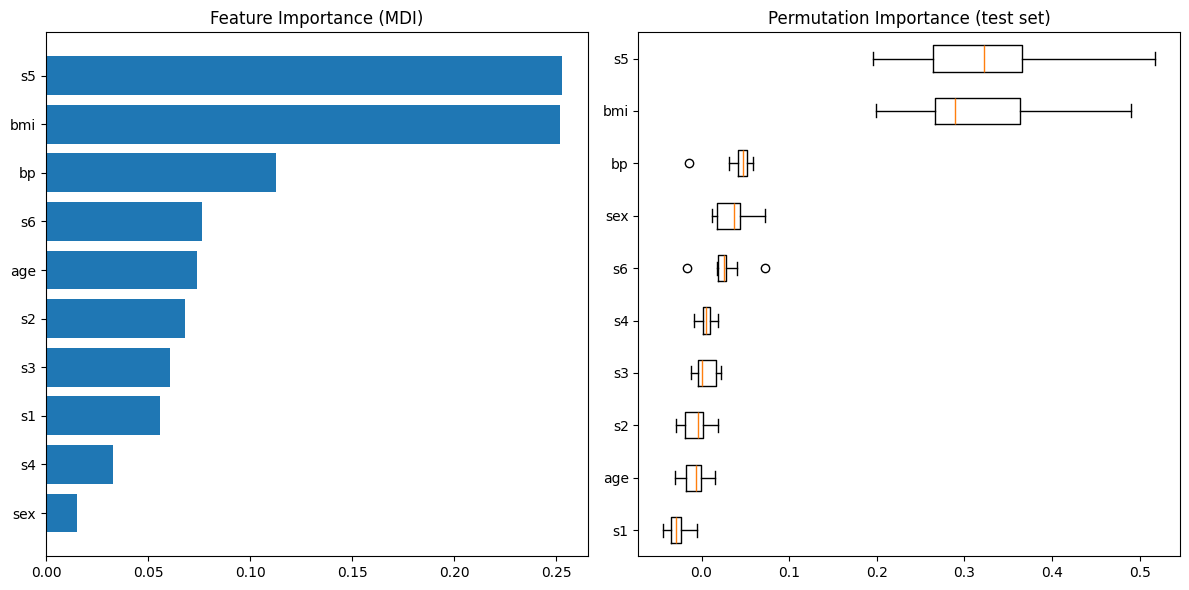

In [21]:
import matplotlib
from sklearn import datasets
diabetes = datasets.load_diabetes()
feature_importance = reg.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(diabetes.feature_names)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    reg, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)

# `labels` argument in boxplot is deprecated in matplotlib 3.9 and has been
# renamed to `tick_labels`. The following code handles this, but as a
# scikit-learn user you probably can write simpler code by using `labels=...`
# (matplotlib < 3.9) or `tick_labels=...` (matplotlib >= 3.9).
tick_labels_parameter_name = (
    "tick_labels"
    if parse_version(matplotlib.__version__) >= parse_version("3.9")
    else "labels"
)
tick_labels_dict = {
    tick_labels_parameter_name: np.array(diabetes.feature_names)[sorted_idx]
}
plt.boxplot(result.importances[sorted_idx].T, vert=False, **tick_labels_dict)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

## XGBoost

In [ ]:
# # ============================================
# # EXAMPLE 1: BASIC USAGE WITH CORE PARAMETERS
# # ============================================

# # REGRESSION EXAMPLE
# reg_model = xgb.XGBRegressor(
#     # Tree-specific parameters
#     n_estimators=100,      # Number of boosting rounds (trees)
#     max_depth=6,           # Maximum tree depth (deeper = more complex)
#     min_child_weight=1,    # Minimum sum of instance weights in a child
    
#     # Learning parameters
#     learning_rate=0.3,     # Step size shrinkage (eta)
#     subsample=1.0,         # Fraction of samples per tree
#     colsample_bytree=1.0,  # Fraction of features per tree
    
#     # Regularization
#     gamma=0,               # Minimum loss reduction for split
#     reg_alpha=0,           # L1 regularization (Lasso)
#     reg_lambda=1,          # L2 regularization (Ridge)
    
#     # Task parameters
#     objective='reg:squarederror',  # Loss function
#     random_state=42
# )

# # CLASSIFICATION EXAMPLE
# clf_model = xgb.XGBClassifier(
#     # Same tree parameters
#     n_estimators=100,
#     max_depth=6,
#     min_child_weight=1,
#     learning_rate=0.3,
#     subsample=1.0,
#     colsample_bytree=1.0,
#     gamma=0,
#     reg_alpha=0,
#     reg_lambda=1,
    
#     # Different objective for classification
#     objective='binary:logistic',  # For binary classification
#     eval_metric='logloss',        # Evaluation metric
#     random_state=42
# )

# print("Basic models created successfully!")

In [2]:
import xgboost as xgb
from sklearn.datasets import make_classification

In [7]:
X, y =  make_classification(n_samples= 1000, n_informative= 5, n_classes= 3)
dtrain = xgb.DMatrix(data=X, label=y) ## for faster training
num_parallel_tree = 4
num_boost_round = 16
# total number of built trees is num_parallel_tree * num_classes * num_boost_round

# We build a boosted random forest for classification here.
booster = xgb.train({
    'num_parallel_tree': 4, 'subsample': 0.5, 'num_class': 3},
                    num_boost_round=num_boost_round, dtrain=dtrain)

# This is the sliced model, containing [3, 7) forests
# step is also supported with some limitations like negative step is invalid.
sliced: xgb.Booster = booster[3:7]

# Access individual tree layer
trees = [_ for _ in booster]
assert len(trees) == num_boost_round

In [9]:
from sklearn.datasets import make_classification
import numpy as np

import xgboost as xgb

# Make a synthetic ranking dataset for demonstration
seed = 1994
X, y = make_classification(random_state=seed)
rng = np.random.default_rng(seed)
n_query_groups = 3
qid = rng.integers(0, n_query_groups, size=X.shape[0])

# Sort the inputs based on query index
sorted_idx = np.argsort(qid)
X = X[sorted_idx, :]
y = y[sorted_idx]
qid = qid[sorted_idx]
ranker = xgb.XGBRanker(tree_method="hist", lambdarank_num_pair_per_sample=8, objective="rank:ndcg", lambdarank_pair_method="topk")
ranker.fit(X, y, qid=qid)

XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=None, device=None,
          early_stopping_rounds=None, enable_categorical=False,
          eval_metric=None, feature_types=None, feature_weights=None,
          gamma=None, grow_policy=None, importance_type=None,
          interaction_constraints=None, lambdarank_num_pair_per_sample=8,
          lambdarank_pair_method='topk', learning_rate=None, max_bin=None,
          max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None,
          max_depth=None, max_leaves=None, min_child_weight=None, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [45]:
## let's run simple classification to understand.
import xgboost as xgb
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

In [39]:
data = load_breast_cancer()
X, y = pd.DataFrame(data.data, columns= data.feature_names), data.target
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size= 0.3, random_state= 42, stratify= y)
## WE use DMatrix for faster computation
dtrain = xgb.DMatrix(data= X_train, label= y_train)
dtest = xgb.DMatrix(data = X_test, label= y_test)


## DMatrix


In [46]:
## we use fit() and predict() in sklearn API
## we have train() and predict() in xgboost API
## catch: we have classifier and regressor in sklearn but we have to pass in xgb API
params = {
    'objective':'binary:logistic',
    'eval_metric' : 'logloss'
}
booster = xgb.train(params, dtrain)
y_predict = booster.predict(dtest)  ##always returns probabilities

preds_proba = booster.predict(dtest)
preds_label = (preds_proba > 0.5).astype(int)

print("Accuracy  :", accuracy_score(y_test, preds_label))
print("ROC AUC   :", roc_auc_score(y_test, preds_proba))  # use proba for AUC
print(classification_report(y_test, preds_label))

Accuracy  : 0.9473684210526315
ROC AUC   : 0.9924065420560748
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



In [ ]:
##default parameters
model_1 = xgb.XGBClassifier(random_state = 42)
model_1.fit(X_train, y_train)
print("accuracy using default pramters:", accuracy_score(y_test, model_1.predict(X_test)))
## increase the no of trees
model_2 = xgb.XGBClassifier(
    n_estimators = 300,
    random_state = 42,
)
model_2.fit(X_train, y_train)
print("accuracy using more trees:", accuracy_score(y_test, model_2.predict(X_test)))
## ntg changes using increasing the no of trees
## try using subsample (At each iteration the base classifier is trained on a fraction subsample of the available training data.)
model_3 = xgb.XGBClassifier(
    subsample = 0.5,
    random_state = 42
)
model_3.fit(X_train, y_train)
print("accuracy using subsample method:", accuracy_score(y_test, model_3.predict(X_test)))



accuracy using default pramters: 0.9649122807017544
accuracy using more trees: 0.9649122807017544
accuracy using subsample method: 0.9473684210526315


In [ ]:
## instead of wanderting around these mutiple parameter we can use hyperparamter tuning
## approach: StratifiedKFold + Early Stopping
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
param_grid = {
    'max_depth': [3,4,5],
    'learning_rate': [0.05, 0.1, 0.3],
    'subsample': [0.5, 0.9]
}
## GridsearchCV doesn't support DMatrix (optuna does)
tuner = GridSearchCV(
    estimator= xgb.XGBClassifier(
        early_stopping_rounds = 20,
        random_state = 42
    ),
    param_grid= param_grid,
    cv=StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42),
    scoring= 'roc_auc',
    refit= True
)
tuner.fit(X_train, y_train, eval_set = [(X_test, y_test)], verbose = False)
print(f"Best params : {tuner.best_params_}")
print(f"CV score    : {tuner.best_score_:.4f}")
print(f"Test score  : {tuner.score(X_test, y_test):.4f}")

Best params : {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.5}
CV score    : 0.9903
Test score  : 0.9937


## Feature importance

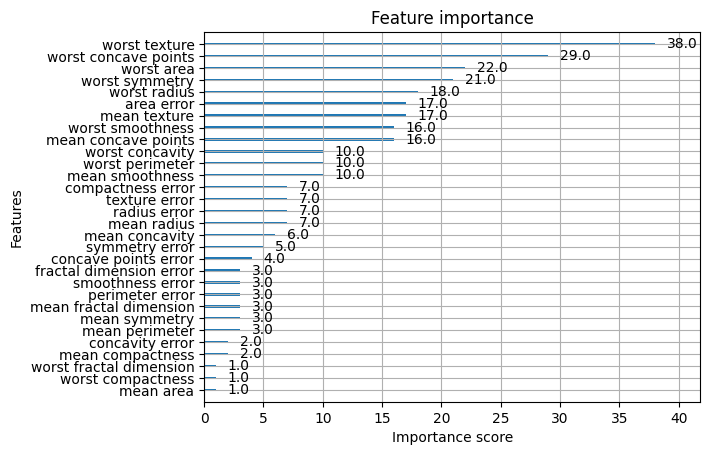

In [34]:
best_model = tuner.best_estimator_
xgb.plot_importance(best_model)
plt.show()

## SHAP

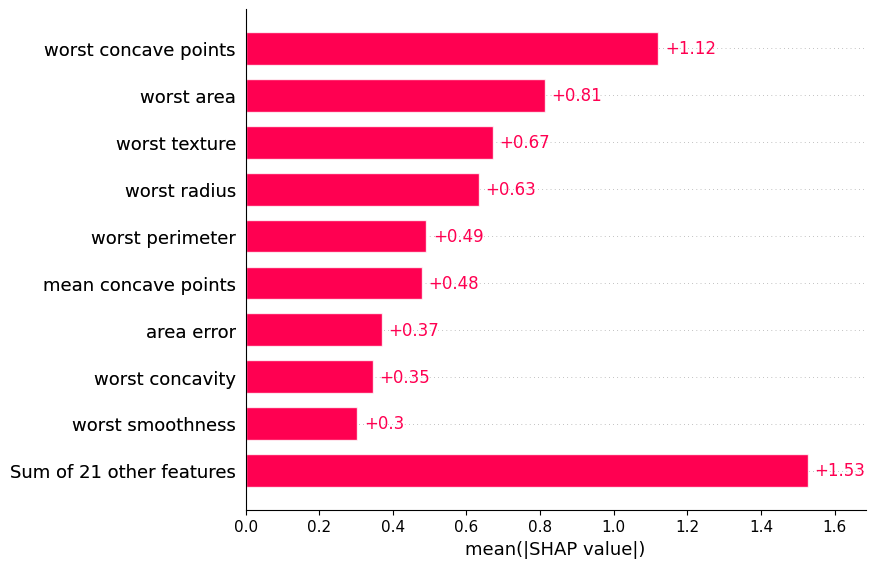

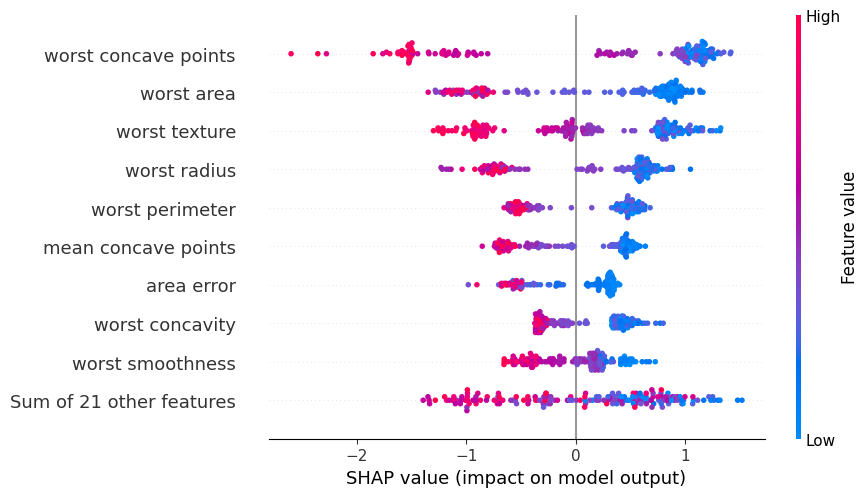

In [38]:
## SHAP : SHAP (SHapley Additive exPlanations) answers "why did the model make this prediction?
# SHAP (SHapley Additive exPlanations) answers "why did the model make this prediction?" by fairly distributing the contribution of each feature to the final output. It borrows from game theory — every feature gets credit or blame based on how much it actually changed the prediction.

import shap
explainer =shap.TreeExplainer(best_model)
shap_vales = explainer.shap_values(X_test)
explanation = shap.Explanation(
    values = shap_vales,
    base_values = explainer.expected_value,
    data = X_test,
    feature_names = load_breast_cancer().feature_names
)
shap.plots.bar(explanation)
shap.plots.beeswarm(explanation)

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import set_config
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])
set_config(display= 'diagram')
pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])